In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
import nrrd
from skimage.metrics import structural_similarity as ssim

In [2]:
target_file = Path("../data/original/285_01_HR_.vol.h5")
file = Path("285_uCT_0915-1830.vol.labels.vec.h5")

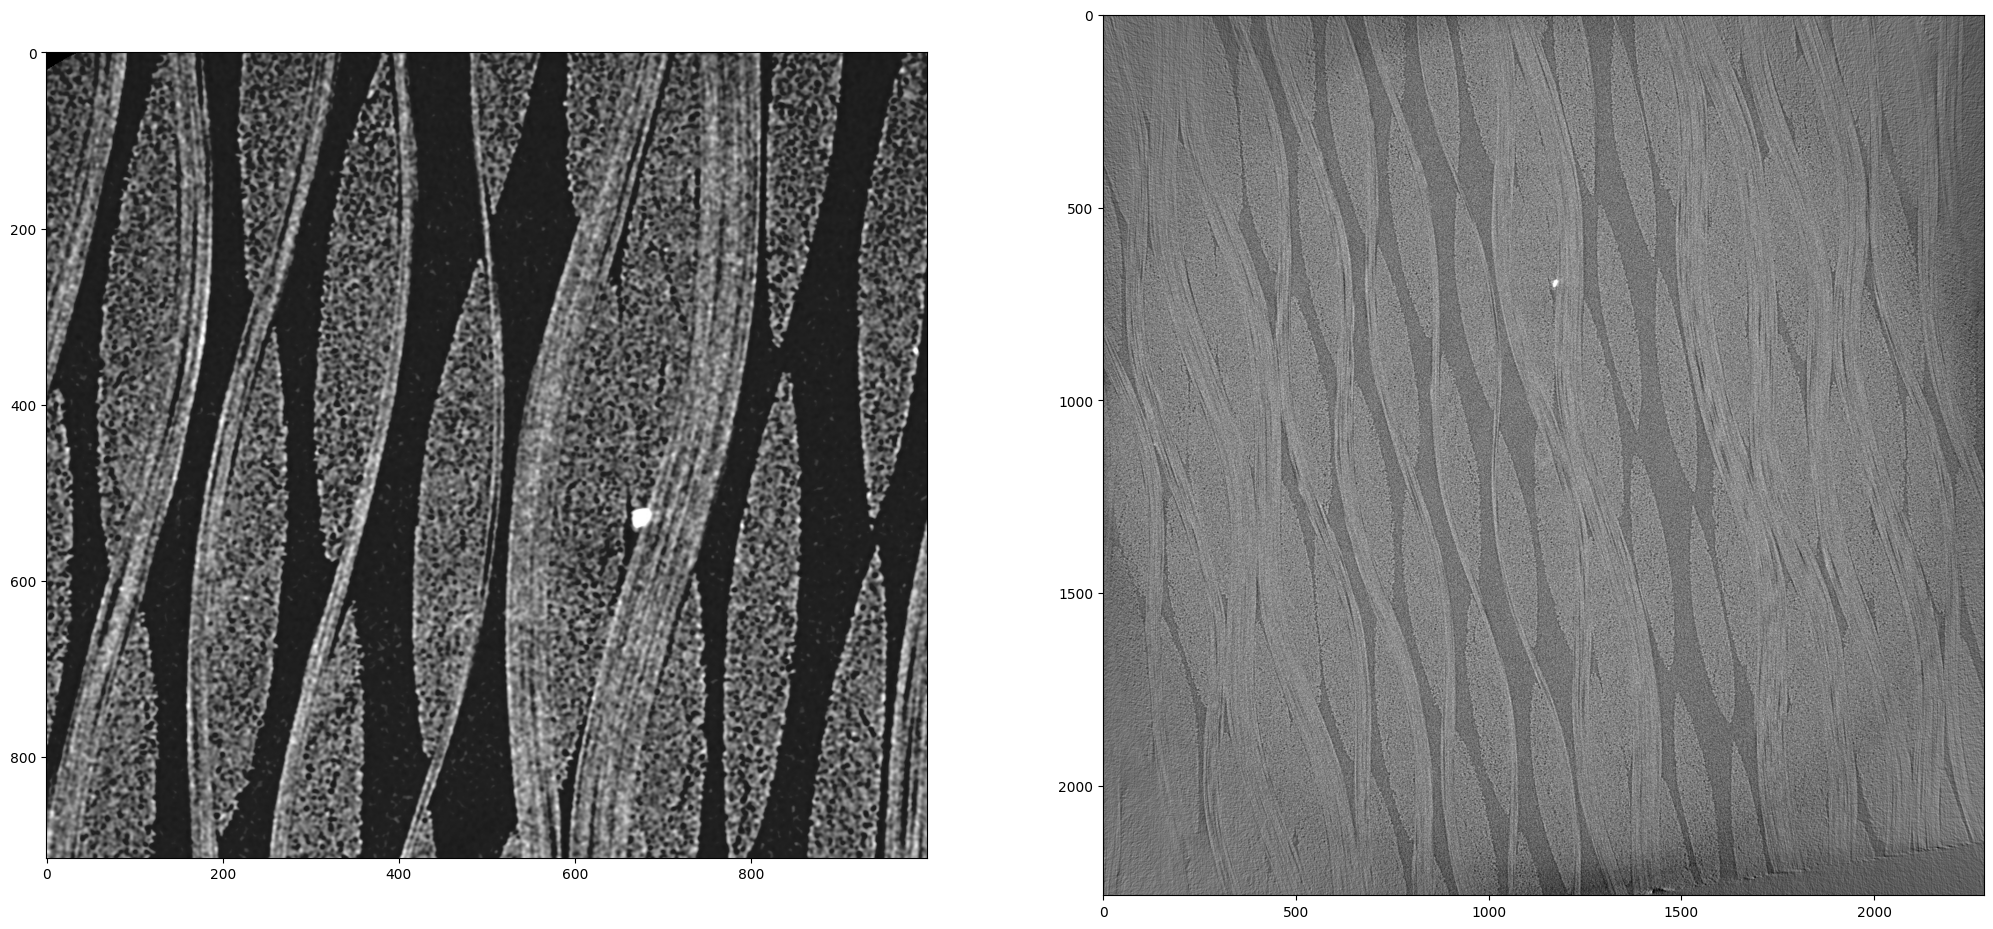

In [3]:
with h5py.File(file,"r") as f:
    ref_raw = f["vol"][:,:,806] # is [ y,z, x] 806

ref_raw = np.flipud(ref_raw[::,::])

with h5py.File(target_file, "r") as f:
    target = f["volume"][873,:,:] # 870


fig, axs = plt.subplots(1,2,figsize=(25,15))
axs[0].imshow(ref_raw,cmap="grey")
axs[1].imshow(target,cmap="grey")

In [4]:
# --------------------------------------------------
# load reference once
# --------------------------------------------------
with h5py.File(file, "r") as f:
    ref_raw = f["vol"][:, :, 806] #806

ref_raw = np.flipud(ref_raw)

In [5]:
# --------------------------------------------------
# helpers
# --------------------------------------------------
def to_uint8(img, p_low=1, p_high=99):
    img = img.astype(np.float32)
    lo, hi = np.percentile(img, [p_low, p_high])
    if hi <= lo:
        return np.zeros_like(img, dtype=np.uint8)
    img = np.clip((img - lo) / (hi - lo), 0, 1)
    return (img * 255).astype(np.uint8)


def preprocess(img):
    img8 = to_uint8(img)
    img8 = cv2.GaussianBlur(img8, (5, 5), 0)
    return img8


def register_affine(ref_img, tgt_img, use_sift=True):
    ref_8 = preprocess(ref_img)
    tgt_8 = preprocess(tgt_img)

    if use_sift and hasattr(cv2, "SIFT_create"):
        detector = cv2.SIFT_create(nfeatures=8000)
        norm_type = cv2.NORM_L2
        ratio = 0.75
    else:
        detector = cv2.ORB_create(
            nfeatures=10000,
            scaleFactor=1.2,
            nlevels=8,
            edgeThreshold=15,
            patchSize=31,
            fastThreshold=10,
        )
        norm_type = cv2.NORM_HAMMING
        ratio = 0.8

    kp_ref, des_ref = detector.detectAndCompute(ref_8, None)
    kp_tgt, des_tgt = detector.detectAndCompute(tgt_8, None)

    if des_ref is None or des_tgt is None:
        return None

    bf = cv2.BFMatcher(norm_type, crossCheck=False)
    matches_knn = bf.knnMatch(des_ref, des_tgt, k=2)

    good = []
    for pair in matches_knn:
        if len(pair) < 2:
            continue
        m, n = pair
        if m.distance < ratio * n.distance:
            good.append(m)

    if len(good) < 8:
        return None

    pts_ref = np.float32([kp_ref[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    pts_tgt = np.float32([kp_tgt[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

    M, inliers = cv2.estimateAffinePartial2D(
        pts_ref,
        pts_tgt,
        method=cv2.RANSAC,
        ransacReprojThreshold=3.0,
        maxIters=5000,
        confidence=0.99,
    )

    if M is None:
        return None

    inliers = inliers.ravel().astype(bool) if inliers is not None else np.zeros(len(good), dtype=bool)
    n_inliers = int(inliers.sum())
    inlier_ratio = n_inliers / max(len(good), 1)

    # reprojection error on inliers
    pts_ref_xy = pts_ref.reshape(-1, 2)
    pts_tgt_xy = pts_tgt.reshape(-1, 2)

    pts_ref_h = np.concatenate([pts_ref_xy, np.ones((pts_ref_xy.shape[0], 1), dtype=np.float32)], axis=1)
    pts_pred = (M @ pts_ref_h.T).T

    err = np.linalg.norm(pts_pred - pts_tgt_xy, axis=1)
    reproj_err = float(err[inliers].mean()) if n_inliers > 0 else np.inf

    # optional ECC score on warped overlap
    h_t, w_t = tgt_8.shape
    warped_ref = cv2.warpAffine(ref_8, M, (w_t, h_t))

    try:
        warp_ecc = np.eye(2, 3, dtype=np.float32)
        criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 100, 1e-5)

        ref_f = warped_ref.astype(np.float32) / 255.0
        tgt_f = tgt_8.astype(np.float32) / 255.0

        ecc_score, _ = cv2.findTransformECC(
            tgt_f, ref_f, warp_ecc,
            motionType=cv2.MOTION_TRANSLATION,
            criteria=criteria
        )
    except cv2.error:
        ecc_score = np.nan

    return {
        "M": M,
        "ref_8": ref_8,
        "tgt_8": tgt_8,
        "warped_ref": warped_ref,
        "kp_ref": kp_ref,
        "kp_tgt": kp_tgt,
        "good": good,
        "inliers_mask": inliers,
        "n_good": len(good),
        "n_inliers": n_inliers,
        "inlier_ratio": inlier_ratio,
        "reproj_err": reproj_err,
        "ecc_score": ecc_score,
    }

In [6]:
# --------------------------------------------------
# loop around target slice 873 ± 5
# --------------------------------------------------
center_idx = 873
delta = 10

results = []

with h5py.File(target_file, "r") as f:
    dset = f["volume"]

    for idx in range(max(0, center_idx - delta), min(dset.shape[0], center_idx + delta + 1)):
        target = dset[idx, :, :]

        res = register_affine(ref_raw, target, use_sift=True)

        if res is None:
            print(f"slice {idx}: failed")
            continue

        results.append({
            "idx": idx,
            **res
        })

        print(
            f"slice {idx}: "
            f"inliers={res['n_inliers']:4d}/{res['n_good']:4d}, "
            f"ratio={res['inlier_ratio']:.3f}, "
            f"reproj={res['reproj_err']:.3f}, "
            f"ecc={res['ecc_score']:.4f}"
        )


if not results:
    raise RuntimeError("No valid registrations found in the tested slice range.")


# --------------------------------------------------
# choose best
# priority: most inliers, then best reprojection error
# --------------------------------------------------
best = sorted(
    results,
    key=lambda r: (-r["n_inliers"], -r["inlier_ratio"], r["reproj_err"])
)[0]

print("\nBest slice:", best["idx"])
print("Best matrix:\n", best["M"])
print("Inliers:", best["n_inliers"], "/", best["n_good"])
print("Inlier ratio:", best["inlier_ratio"])
print("Reprojection error:", best["reproj_err"])
print("ECC:", best["ecc_score"])

slice 863: failed
slice 864: failed
slice 865: failed
slice 866: inliers=   2/  10, ratio=0.200, reproj=0.000, ecc=nan
slice 867: inliers=   2/  13, ratio=0.154, reproj=0.000, ecc=0.0628
slice 868: inliers=   2/   8, ratio=0.250, reproj=0.000, ecc=0.2377
slice 869: inliers=  10/  15, ratio=0.667, reproj=0.666, ecc=0.2888
slice 870: inliers=  10/  13, ratio=0.769, reproj=0.758, ecc=0.3022
slice 871: inliers=  10/  18, ratio=0.556, reproj=0.633, ecc=0.3082
slice 872: inliers=   7/  10, ratio=0.700, reproj=0.645, ecc=0.3121
slice 873: inliers=  16/  23, ratio=0.696, reproj=0.557, ecc=0.3141
slice 874: inliers=  11/  15, ratio=0.733, reproj=0.381, ecc=0.3133
slice 875: inliers=  13/  20, ratio=0.650, reproj=0.386, ecc=0.3098
slice 876: inliers=  13/  18, ratio=0.722, reproj=0.467, ecc=0.3046
slice 877: inliers=  17/  26, ratio=0.654, reproj=0.506, ecc=0.3005
slice 878: inliers=  10/  15, ratio=0.667, reproj=0.474, ecc=0.2930
slice 879: inliers=   8/  17, ratio=0.471, reproj=0.815, ecc=0.29

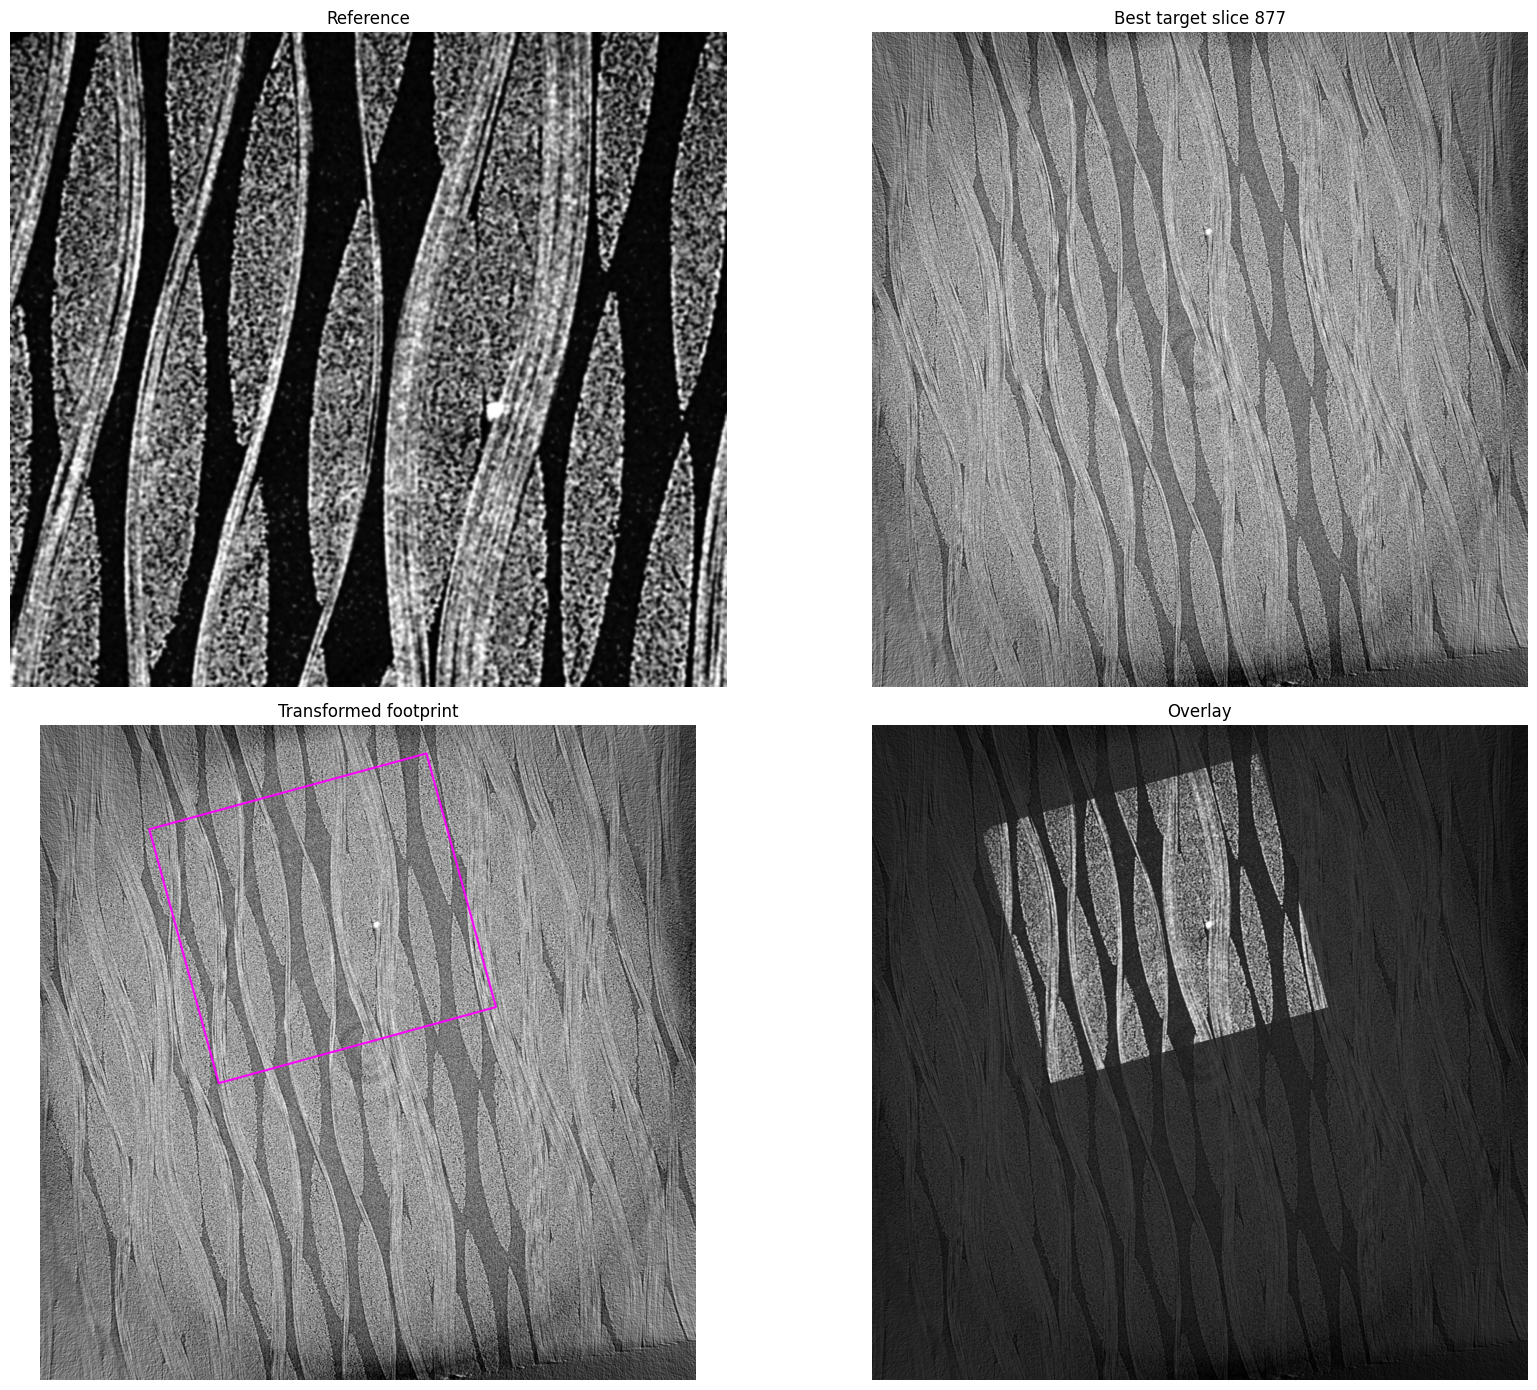

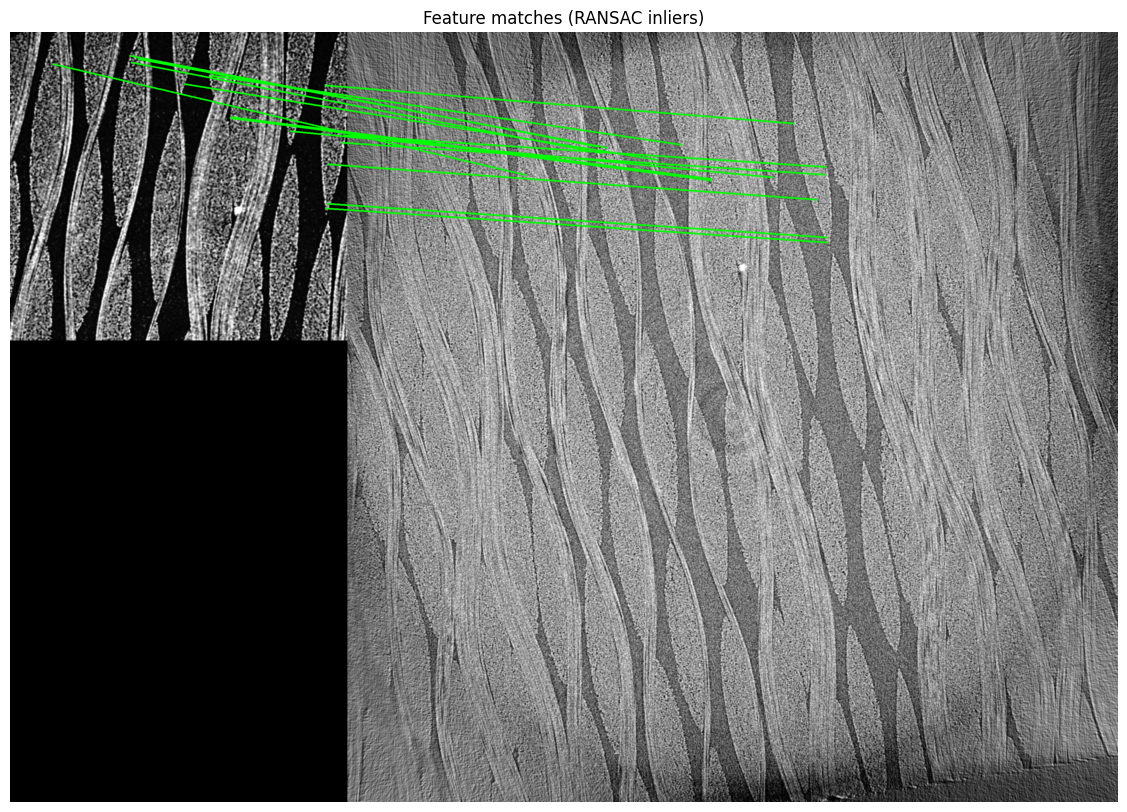

In [8]:
M = best["M"]
ref_8 = best["ref_8"]
tgt_8 = best["tgt_8"]
warped_ref = best["warped_ref"]

overlay = cv2.addWeighted(tgt_8, 0.3, warped_ref, 0.7, 0)

h_r, w_r = ref_8.shape
corners = np.float32([
    [0, 0],
    [w_r, 0],
    [w_r, h_r],
    [0, h_r]
]).reshape(-1, 1, 2)

corners_t = cv2.transform(corners, M)
corners_t_int = np.int32(corners_t)

target_vis = cv2.cvtColor(tgt_8, cv2.COLOR_GRAY2BGR)
cv2.polylines(target_vis, [corners_t_int], isClosed=True, color=(255, 0, 255), thickness=5)

matches_mask = best["inliers_mask"].astype(int).tolist()

match_img = cv2.drawMatches(
    ref_8, best["kp_ref"],
    tgt_8, best["kp_tgt"],
    best["good"], None,
    matchesMask=matches_mask,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

# draw thicker lines on top
h1, w1 = ref_8.shape[:2]

for i, m in enumerate(best["good"]):
    if matches_mask is not None and not matches_mask[i]:
        continue

    pt1 = tuple(map(int, best["kp_ref"][m.queryIdx].pt))
    pt2 = tuple(map(int, best["kp_tgt"][m.trainIdx].pt))
    pt2 = (int(pt2[0] + w1), int(pt2[1]))  # shift for concatenated image

    cv2.line(match_img, pt1, pt2, (0, 255, 0), thickness=3)  # ← thicker


fig, axs = plt.subplots(2, 2, figsize=(18, 14))

axs[0, 0].imshow(ref_8, cmap="gray")
axs[0, 0].set_title("Reference")
axs[0, 0].axis("off")

axs[0, 1].imshow(tgt_8, cmap="gray")
axs[0, 1].set_title(f"Best target slice {best['idx']}")
axs[0, 1].axis("off")

axs[1, 0].imshow(target_vis[..., ::-1])
axs[1, 0].set_title("Transformed footprint")
axs[1, 0].axis("off")

axs[1, 1].imshow(overlay, cmap="gray")
axs[1, 1].set_title("Overlay")
axs[1, 1].axis("off")

plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 10))
plt.imshow(match_img)
plt.title("Feature matches (RANSAC inliers)")
plt.axis("off")
plt.show()

In [ ]:
def ref_to_target_z(z_ref, n_slices=1684):
    return (n_slices - 1) - z_ref




In [29]:
# -----------------------------
# known registration result
# -----------------------------
target_center = best["idx"]
ref_offset = 806
n_slices = 1000

target_stop = ref_to_target_z(0) 
target_start = ref_to_target_z(n_slices)

M = best["M"]


M_inv = cv2.invertAffineTransform(M)

# reference grid size
h_ref = 915
w_ref = 1000

# output stack on ref grid
out = np.zeros((h_ref, w_ref, n_slices), dtype=np.uint16)

with h5py.File(target_file, "r") as f:
    dset = f["volume"]   # assumed [x, y, z]

    if target_start < 0 or target_stop > dset.shape[0]:
        raise ValueError(
            f"Requested target slice range [{target_start}, {target_stop}) "
            f"is outside volume with shape {dset.shape}"
        )

    for j, idx in enumerate(range(target_start, target_stop)):
        target_slice = dset[idx, :, :]   # 2D slice

        warped = cv2.warpAffine(
            target_slice.astype(np.float32),
            M_inv,
            (w_ref, h_ref),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_CONSTANT,
            borderValue=0
        )

        out[:, :, n_slices - 1 - j] = np.clip(
                np.flipud(warped), 0, np.iinfo(np.uint16).max
            ).astype(np.uint16)

print(out.shape)  # (915, 1000, 1000)

(915, 1000, 1000)


img1 shape: (915, 1000)
img2 shape: (915, 1000)
Cos similarity  : 0.919793
SSIM            : 0.184550
MSE             : 0.061947
MAE             : 0.210661


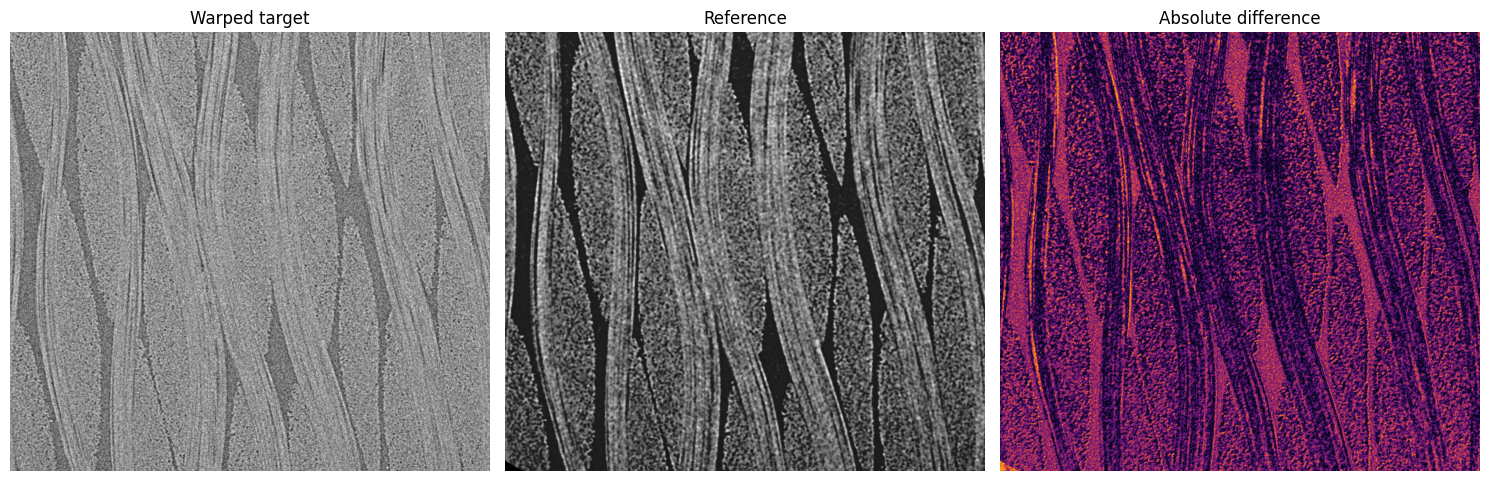

In [32]:
slice_test = -1

with h5py.File(file, "r") as f:
    ref_raw = f["vol"][:, :, slice_test]   # [y, z, x] -> 2D slice

img1 = out[:, :, slice_test].astype(np.float32)
img2 = ref_raw.astype(np.float32)

print("img1 shape:", img1.shape)
print("img2 shape:", img2.shape)


def normalize01(img):
    img = img.astype(np.float32)
    mn = img.min()
    mx = img.max()
    if mx <= mn:
        return np.zeros_like(img, dtype=np.float32)
    return (img - mn) / (mx - mn)


def cosine_similarity(a, b):
    a = a.astype(np.float32).ravel()
    b = b.astype(np.float32).ravel()
    na = np.linalg.norm(a)
    nb = np.linalg.norm(b)
    if na < 1e-12 or nb < 1e-12:
        return np.nan
    return float(np.dot(a, b) / (na * nb))


# normalize for intensity-based metrics
img1n = normalize01(img1)
img2n = normalize01(img2)

mse = np.mean((img1n - img2n) ** 2)
mae = np.mean(np.abs(img1n - img2n))
cos_val = cosine_similarity(img1, img2)
ssim_val = ssim(img1n, img2n, data_range=1.0)

print(f"Cos similarity  : {cos_val:.6f}")
print(f"SSIM            : {ssim_val:.6f}")
print(f"MSE             : {mse:.6f}")
print(f"MAE             : {mae:.6f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img1, cmap="gray")
ax[0].set_title("Warped target")
ax[0].axis("off")

ax[1].imshow(img2, cmap="gray")
ax[1].set_title("Reference")
ax[1].axis("off")

ax[2].imshow(np.abs(img1n - img2n), cmap="inferno")
ax[2].set_title("Absolute difference")
ax[2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:

with h5py.File("285_uCT_0915-1830.vol.labels.vec.h5","a") as F:
    F.create_dataset("vol_", data=out,compression="gzip")



In [37]:
nrrd.write("285_uCT_0915-1830.vol_.nrrd", out.astype(np.uint16))

In [7]:
vol_, _ = nrrd.read("285_uCT_0915-1830.vol_.nrrd")
vol, _ = nrrd.read("285_uCT_0915-1830.vol.nrrd")
labels, _ = nrrd.read("285_uCT_0915-1830.pred.nrrd")

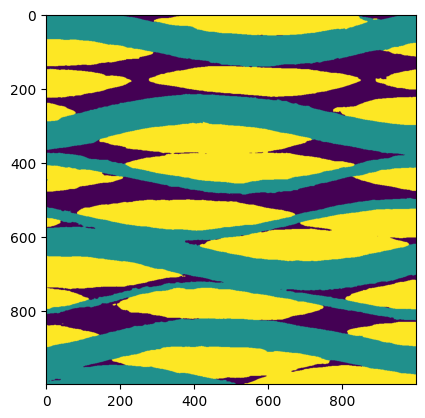

In [10]:
plt.imshow(labels[0,:,:])

In [11]:


with h5py.File("285_uCT_0915-1830.vol.labels.vec.h5","w") as F:
    F.create_dataset("vol_", data=vol_.astype(np.uint16),compression="gzip")
    F.create_dataset("vol", data=vol.astype(np.uint8),compression="gzip")
    F.create_dataset("labels", data=labels.astype(np.uint8),compression="gzip")
